## Explanation for Task 4

In this task, I analyzed the word count distribution of the abstract/summary from the arxiv papers collected in Task 1.

First, I loaded the `arxiv_papers_2025.csv` file and the abstract text for each paper is stored in the `summary` column. I calculated the word count for each abstract by splitting the summary text into words and counting the number of words.

After calculating the word counts, I printed basic information such as the minimum and maximum abstract word count. I also created word count ranges using bins of 20 words, such as 0-19, 20-39 and so on. This helped me summarize how many papers fall into each word count range.

Finally, I created a histogram using Matplotlib to visualize the distribution of abstract word counts. The x-axis shows the number of words in the abstract, and the y-axis shows the number of papers.

In [7]:
# Task 4 - Creating a Histogram of 'Summary' Word Count Distribution
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loading the data from Task 1
df = pd.read_csv("/content/sample_data/arxiv_papers_2025.csv")

print(f"Total papers: {len(df)}")
df["summary"].head()

Total papers: 400


,summary
0,Trajectory prediction methods have been widely...
1,Photoevaporation in exoplanet atmospheres is t...
2,The cosmography known as the Padé polynomials ...
3,We study the propagation of energy in one-dime...
4,We show that the abelian Livšic theorem recent...


In [8]:
# Calculating the word count for each summary

# Counting words by splitting on whitespaces
df["word_count"] = df["summary"].str.split().str.len()

print(f"Word count stats:")
print(f"  Min:    {df['word_count'].min()}")
print(f"  Max:    {df['word_count'].max()}")

Word count stats:
  Min:    25
  Max:    311


In [15]:
# Creating a bins of 20 words
bins = list(range(0, df["word_count"].max() + 20, 20))
labels = [f"{i}-{i+19}" for i in range(0, df["word_count"].max(), 20)]

df["word_count_range"] = pd.cut(df["word_count"], bins=bins, labels=labels, right=False)

freq_table = df["word_count_range"].value_counts().sort_index()

freq_table = freq_table[freq_table > 0]

print("Word Count Range and Number of Papers")
for word_range, count in freq_table.items():
    print(f"  {word_range:>10} words  -  {count} papers")

Word Count Range and Number of Papers
       20-39 words  -  4 papers
       40-59 words  -  9 papers
       60-79 words  -  12 papers
       80-99 words  -  18 papers
     100-119 words  -  27 papers
     120-139 words  -  39 papers
     140-159 words  -  55 papers
     160-179 words  -  49 papers
     180-199 words  -  58 papers
     200-219 words  -  50 papers
     220-239 words  -  34 papers
     240-259 words  -  24 papers
     260-279 words  -  12 papers
     280-299 words  -  8 papers
     300-319 words  -  1 papers


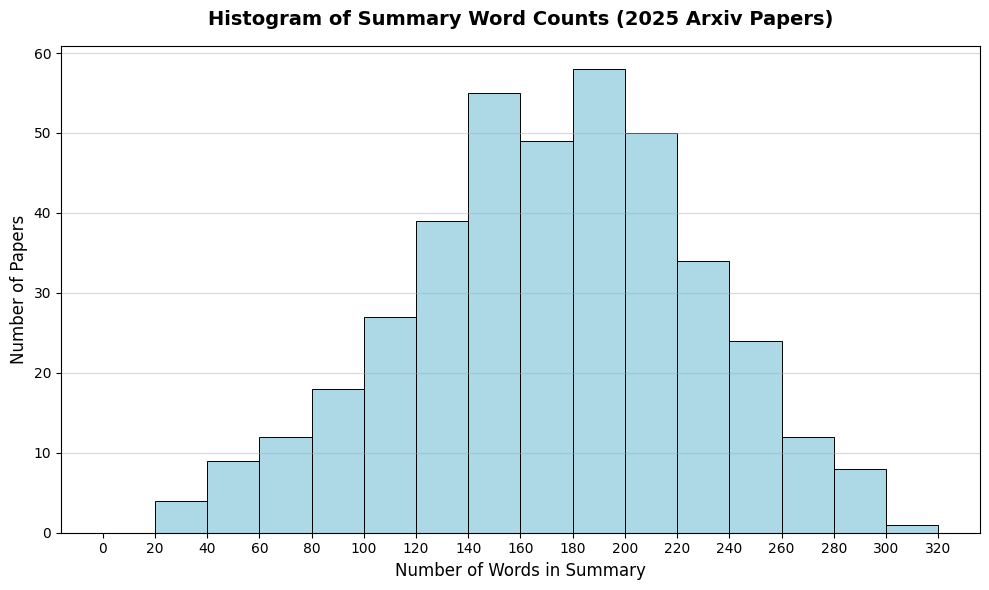

In [11]:
# Plotting the graph based on the word count distribution

fig, ax = plt.subplots(figsize=(10, 6))

bin_edges = list(range(0, df["word_count"].max() + 20, 20))

ax.hist(df["word_count"], bins=bin_edges, color="lightblue", edgecolor="black", linewidth=0.7)

ax.set_title("Histogram of Summary Word Counts (2025 Arxiv Papers)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Number of Words in Summary", fontsize=12)
ax.set_ylabel("Number of Papers", fontsize=12)

ax.set_xticks(np.arange(0, df["word_count"].max() + 20, 20))

ax.grid(axis="y", alpha=0.5)

plt.tight_layout()
plt.show()